# Convergence-matched U-Tikhonov 2×2 continuation

This notebook continues the three non-principal U-Tikhonov ablations
from their original 20-epoch latest checkpoints to epoch 300. It
uses the same staged schedule as the principal T16/CG32 run:

`20 → 100 → 200 → 300`.

The experiment changes only two factors:

| Configuration | λ upper-bound multiplier | Fixed CG iterations |
|---|---:|---:|
| T4/CG32 | 4 | 32 |
| T4/CG64 | 4 | 64 |
| T16/CG32 (already complete) | 16 | 32 |
| T16/CG64 | 16 | 64 |

The three continuations preserve AdamW state. The dataset split remains
fixed by seed 42; the first legacy continuation uses seed 1,000,042 for
shuffling and stochastic training noise. From that point onward, RNG
and loader-generator states are stored and restored exactly.

The notebook is restart-safe at completed epochs. If execution stops
during an epoch, rerunning resumes from the preceding saved epoch.
Validation PSNR selects the checkpoint, but every configuration trains
for the full 300 epochs.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Put this notebook in "
        "cleaned_pipeline/notebooks or start Jupyter from the project."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


In [2]:
import gc
import random
import shutil
import time
from argparse import Namespace
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from src.evaluation.benchmark import load_checkpoint, load_project_model
from src.evaluation.denoising_eval import (
    evaluate_denoising_model,
    summarize_results,
    unpack_model_output,
)
from src.training.denoising import (
    build_seaturtle_loaders,
    describe_device,
    get_device,
    seed_everything,
    synchronize_device,
)

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0
Device: mps


## Configuration

`RUN_METHODS` can be reduced to one label if the runs should be
launched separately. Completed stages are detected and skipped, so the
default list is safe to rerun.


In [3]:
SEA_TURTLE_ROOT = Path(
    "/Users/kyrillguba/.cache/kagglehub/datasets/"
    "wildlifedatasets/seaturtleid2022/versions/4"
).expanduser()

CONTINUATION_SEED = 1_000_042
SPLIT_SEED = 42
STAGE_TARGETS = (100, 200, 300)
LAMBDA_MIN = 1e-4

EXPERIMENTS = OrderedDict(
    [
        (
            "U-Tikhonov T4/CG32",
            {
                "multiplier": 4.0,
                "cg_iters": 32,
                "legacy_run": "u_tikhonov_bounded_cg32",
                "canonical_run": "u_tikhonov_bounded_x4_cg32",
            },
        ),
        (
            "U-Tikhonov T4/CG64",
            {
                "multiplier": 4.0,
                "cg_iters": 64,
                "legacy_run": "u_tikhonov_bounded_x4_cg64",
                "canonical_run": "u_tikhonov_bounded_x4_cg64",
            },
        ),
        (
            "U-Tikhonov T16/CG64",
            {
                "multiplier": 16.0,
                "cg_iters": 64,
                "legacy_run": "u_tikhonov_bounded_x16_cg64",
                "canonical_run": "u_tikhonov_bounded_x16_cg64",
            },
        ),
    ]
)

RUN_METHODS = list(EXPERIMENTS)
PRINT_EVERY = 50

if not SEA_TURTLE_ROOT.is_dir():
    raise FileNotFoundError(
        f"SeaTurtle root not found: {SEA_TURTLE_ROOT}. "
        "Edit SEA_TURTLE_ROOT before continuing."
    )

display(
    pd.DataFrame(
        [
            {
                "method": method,
                "lambda_multiplier": spec["multiplier"],
                "cg_iterations": spec["cg_iters"],
                "source_run": spec["legacy_run"],
            }
            for method, spec in EXPERIMENTS.items()
        ]
    )
)


,method,lambda_multiplier,cg_iterations,source_run
0,U-Tikhonov T4/CG32,4.0,32,u_tikhonov_bounded_cg32
1,U-Tikhonov T4/CG64,4.0,64,u_tikhonov_bounded_x4_cg64
2,U-Tikhonov T16/CG64,16.0,64,u_tikhonov_bounded_x16_cg64


## Preflight and continuation helpers

The preflight check reads model settings from each checkpoint and
verifies the two ablation factors before any optimizer update occurs.


In [4]:
def optional_float(value, default=None):
    if value is None or str(value).lower() == "none":
        return default
    return float(value)


def source_latest_path(spec):
    return (
        PROJECT_ROOT
        / "checkpoints"
        / spec["legacy_run"]
        / "u_tikhonov_latest.pth"
    )


def stage_run_name(spec, target_epoch):
    source_epoch = 20 if target_epoch == 100 else target_epoch - 100
    return (
        f"{spec['canonical_run']}_e{target_epoch}"
        f"_resumed_from_e{source_epoch}"
    )


def stage_dir(spec, target_epoch):
    return PROJECT_ROOT / "checkpoints" / stage_run_name(spec, target_epoch)


def stage_source_dir(spec, target_epoch):
    if target_epoch == 100:
        return source_latest_path(spec).parent
    return stage_dir(spec, target_epoch - 100)


def checkpoint_args(checkpoint):
    return dict(checkpoint.get("args", {}))


def make_training_args(checkpoint, checkpoint_dir, target_epoch):
    saved = checkpoint_args(checkpoint)
    return Namespace(
        data_root=str(SEA_TURTLE_ROOT),
        checkpoint_dir=str(checkpoint_dir),
        image_size=int(saved.get("image_size", 256)),
        max_images=int(saved.get("max_images", 550)),
        val_images=int(saved.get("val_images", 50)),
        sigma_min=float(saved.get("sigma_min", 0.0)),
        sigma_max=float(saved.get("sigma_max", 0.2)),
        val_sigma=float(saved.get("val_sigma", 0.1)),
        val_noise_seed=int(saved.get("val_noise_seed", 10_000)),
        base_channels=int(saved.get("base_channels", 32)),
        depth=int(saved.get("depth", 3)),
        cg_iters=int(saved["cg_iters"]),
        cg_relative_tol=float(saved.get("cg_relative_tol", 1e-7)),
        reference_lambda=float(saved.get("reference_lambda", 2.49805)),
        map_scale=optional_float(saved.get("map_scale"), 0.1),
        lambda_parameterization=str(
            saved.get("lambda_parameterization", "bounded_sigmoid")
        ),
        lambda_min=float(saved.get("lambda_min", LAMBDA_MIN)),
        lambda_max=float(saved["lambda_max"]),
        epochs=int(target_epoch),
        batch_size=int(saved.get("batch_size", 1)),
        lr=float(saved.get("lr", 1e-4)),
        weight_decay=float(saved.get("weight_decay", 1e-5)),
        grad_clip=float(saved.get("grad_clip", 1.0)),
        num_workers=int(saved.get("num_workers", 0)),
        print_every=PRINT_EVERY,
        seed=SPLIT_SEED,
        device=None,
        clamp_for_metrics=bool(saved.get("clamp_for_metrics", True)),
    )


def preflight(method, spec):
    path = source_latest_path(spec)
    if not path.is_file():
        raise FileNotFoundError(f"Missing 20-epoch latest checkpoint: {path}")
    checkpoint = load_checkpoint(path, "cpu")
    args = checkpoint_args(checkpoint)
    source_epoch = int(checkpoint["epoch"])
    if source_epoch != 20:
        raise RuntimeError(
            f"{method}: expected source epoch 20, found {source_epoch}."
        )
    if int(args["cg_iters"]) != int(spec["cg_iters"]):
        raise RuntimeError(f"{method}: CG depth does not match specification.")
    reference = float(args["reference_lambda"])
    expected_max = float(spec["multiplier"]) * reference
    actual_max = float(args["lambda_max"])
    if not np.isclose(actual_max, expected_max, rtol=1e-7, atol=1e-9):
        raise RuntimeError(
            f"{method}: lambda_max={actual_max}, expected {expected_max}."
        )
    if str(args.get("lambda_parameterization")) != "bounded_sigmoid":
        raise RuntimeError(f"{method}: expected bounded_sigmoid.")
    history_path = path.parent / "history.csv"
    history = pd.read_csv(history_path)
    if int(history["epoch"].max()) != 20:
        raise RuntimeError(f"{method}: source history does not end at epoch 20.")
    return {
        "method": method,
        "source": str(path),
        "source_epoch": source_epoch,
        "reference_lambda": reference,
        "lambda_max": actual_max,
        "cg_iters": int(args["cg_iters"]),
        "optimizer_saved": "optimizer_state_dict" in checkpoint,
    }


preflight_table = pd.DataFrame(
    [preflight(method, EXPERIMENTS[method]) for method in RUN_METHODS]
)
if not preflight_table["optimizer_saved"].all():
    raise RuntimeError("Every source checkpoint must contain AdamW state.")
display(preflight_table)


,method,source,source_epoch,reference_lambda,lambda_max,cg_iters,optimizer_saved
0,U-Tikhonov T4/CG32,/Users/kyrillguba/Documents/Data Analytics MSc...,20,2.080084,8.320335,32,True
1,U-Tikhonov T4/CG64,/Users/kyrillguba/Documents/Data Analytics MSc...,20,2.080084,8.320335,64,True
2,U-Tikhonov T16/CG64,/Users/kyrillguba/Documents/Data Analytics MSc...,20,2.080084,33.281341,64,True


In [5]:
def capture_rng_state(train_loader):
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
    }

    if torch.cuda.is_available():
        state["torch_cuda"] = torch.cuda.get_rng_state_all()

    generator = getattr(train_loader, "generator", None)
    if generator is not None:
        state["train_loader_generator"] = generator.get_state()

    return state

def _cpu_byte_rng_state(value):
    """Convert a saved RNG state to the format required by PyTorch."""
    if torch.is_tensor(value):
        return (
            value.detach()
            .to(device="cpu", dtype=torch.uint8)
            .contiguous()
        )
    return torch.as_tensor(
        value,
        dtype=torch.uint8,
        device="cpu",
    ).contiguous()


def restore_or_seed_rng(checkpoint, train_loader):
    state = checkpoint.get("rng_state")
    restored = isinstance(state, dict) and "torch_cpu" in state

    if restored:
        random.setstate(state["python"])
        np.random.set_state(state["numpy"])

        # Saved CPU RNG tensors may have been moved to MPS by
        # torch.load(..., map_location=device).
        torch.set_rng_state(
            _cpu_byte_rng_state(state["torch_cpu"])
        )

        if torch.cuda.is_available() and "torch_cuda" in state:
            cuda_states = [
                _cpu_byte_rng_state(cuda_state)
                for cuda_state in state["torch_cuda"]
            ]
            torch.cuda.set_rng_state_all(cuda_states)

        generator = getattr(train_loader, "generator", None)
        if (
            generator is not None
            and "train_loader_generator" in state
        ):
            generator.set_state(
                _cpu_byte_rng_state(
                    state["train_loader_generator"]
                )
            )
    else:
        seed_everything(CONTINUATION_SEED)
        generator = getattr(train_loader, "generator", None)
        if generator is not None:
            generator.manual_seed(CONTINUATION_SEED)

    return restored

def optimizer_step_bounds(optimizer):
    steps = []
    for state in optimizer.state.values():
        step = state.get("step")
        if step is None:
            continue
        if torch.is_tensor(step):
            step = step.detach().cpu().item()
        steps.append(int(step))
    if not steps:
        return None, None
    return min(steps), max(steps)


def plain_args(args):
    return {
        key: str(value) if isinstance(value, (Path, torch.device)) else value
        for key, value in vars(args).items()
    }


def release_accelerator():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()


In [6]:
def continue_stage(method, spec, target_epoch):
    destination = stage_dir(spec, target_epoch)
    destination.mkdir(parents=True, exist_ok=True)
    destination_latest = destination / "u_tikhonov_latest.pth"
    destination_best = destination / "u_tikhonov_best.pth"
    destination_history = destination / "history.csv"

    expected_source_epoch = 20 if target_epoch == 100 else target_epoch - 100
    source_directory = stage_source_dir(spec, target_epoch)
    source_latest = source_directory / "u_tikhonov_latest.pth"
    source_best = source_directory / "u_tikhonov_best.pth"
    source_history = source_directory / "history.csv"

    if not source_latest.is_file() or not source_history.is_file():
        raise FileNotFoundError(
            f"{method}: missing source for stage {expected_source_epoch}→"
            f"{target_epoch}: {source_directory}"
        )

    if destination_latest.is_file():
        current_path = destination_latest
        current_history_path = destination_history
    else:
        current_path = source_latest
        current_history_path = source_history
        if not destination_best.exists():
            if not source_best.is_file():
                raise FileNotFoundError(f"Missing source best checkpoint: {source_best}")
            shutil.copy2(source_best, destination_best)

    checkpoint = load_checkpoint(current_path, device)
    start_epoch = int(checkpoint["epoch"])
    history = pd.read_csv(current_history_path)
    if int(history["epoch"].max()) != start_epoch:
        raise RuntimeError(
            f"{method}: checkpoint epoch {start_epoch} and history disagree."
        )
    if start_epoch < expected_source_epoch or start_epoch > target_epoch:
        raise RuntimeError(
            f"{method}: invalid start epoch {start_epoch} for target {target_epoch}."
        )
    if start_epoch == target_epoch:
        print(f"Skipping completed stage: {method}, epoch {target_epoch}")
        return destination

    args = make_training_args(checkpoint, destination, target_epoch)
    train_loader, val_loader = build_seaturtle_loaders(args)
    if len(train_loader.dataset) != 500 or len(val_loader.dataset) != 50:
        raise RuntimeError("Expected the fixed 500/50 SeaTurtle split.")

    model, loaded_checkpoint = load_project_model(current_path, device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=args.lr, weight_decay=args.weight_decay
    )
    optimizer.load_state_dict(loaded_checkpoint["optimizer_state_dict"])
    step_min_before, step_max_before = optimizer_step_bounds(optimizer)
    rng_restored = restore_or_seed_rng(loaded_checkpoint, train_loader)

    best_row = history.loc[history["val_psnr"].idxmax()]
    best_val_psnr = float(best_row["val_psnr"])
    best_epoch = int(best_row["epoch"])
    prior_total = float(history["total_time_sec"].iloc[-1])
    parameter_count = sum(parameter.numel() for parameter in model.parameters())

    synchronize_device(device)
    stage_start = time.perf_counter()
    print(
        f"\n{method}: continuing epoch {start_epoch} → {target_epoch} | "
        f"Adam steps {step_min_before}–{step_max_before} | "
        f"RNG restored={rng_restored}"
    )

    for epoch in range(start_epoch + 1, target_epoch + 1):
        synchronize_device(device)
        epoch_start = time.perf_counter()
        train_start = epoch_start
        model.train()
        loss_sum = 0.0
        sample_count = 0

        for step, batch in enumerate(train_loader, start=1):
            noisy = batch["noisy"].to(device)
            clean = batch["clean"].to(device)
            reconstruction, _ = unpack_model_output(model(noisy))
            loss = F.mse_loss(reconstruction, clean)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if args.grad_clip is not None and args.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), args.grad_clip)
            optimizer.step()

            batch_size = int(clean.shape[0])
            loss_sum += float(loss.item()) * batch_size
            sample_count += batch_size
            if args.print_every > 0 and step % args.print_every == 0:
                print(
                    f"Epoch {epoch:03d} | batch {step:04d}/{len(train_loader):04d} "
                    f"| train MSE {loss.item():.6e}"
                )

        synchronize_device(device)
        train_time = time.perf_counter() - train_start
        validation_start = time.perf_counter()
        val_table = evaluate_denoising_model(
            model,
            val_loader,
            device,
            model_type="u_tikhonov",
            clamp_for_metrics=args.clamp_for_metrics,
        )
        synchronize_device(device)
        validation_time = time.perf_counter() - validation_start
        val = summarize_results(val_table)
        epoch_time = time.perf_counter() - epoch_start
        cumulative_total = prior_total + (time.perf_counter() - stage_start)

        row = {
            "epoch": epoch,
            "train_mse": loss_sum / sample_count,
            "val_mse": val["recon_mse"],
            "val_psnr": val["recon_psnr"],
            "val_ssim": val["recon_ssim"],
            "noisy_mse": val["noisy_mse"],
            "noisy_psnr": val["noisy_psnr"],
            "noisy_ssim": val["noisy_ssim"],
            "train_phase_time_sec": train_time,
            "validation_time_sec": validation_time,
            "epoch_time_sec": epoch_time,
            "total_time_sec": cumulative_total,
            "train_images_per_sec": sample_count / train_time,
            "validation_images_per_sec": len(val_loader.dataset) / validation_time,
        }
        for key, value in val.items():
            if key not in row and key not in {
                "recon_mse", "recon_psnr", "recon_ssim"
            }:
                row[f"val_{key}"] = value

        history = pd.concat([history, pd.DataFrame([row])], ignore_index=True)
        history.to_csv(destination_history, index=False)

        payload = {
            "epoch": epoch,
            "model_name": "u_tikhonov",
            "resolved_device": str(device),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "args": plain_args(args),
            "val_metrics": val,
            "parameter_names": tuple(getattr(model, "parameter_names", ())),
            "history": history.to_dict("records"),
            "rng_state": capture_rng_state(train_loader),
            "continuation": {
                "method": method,
                "initial_source_epoch": expected_source_epoch,
                "target_epoch": target_epoch,
                "continuation_seed": CONTINUATION_SEED,
                "rng_restored_at_stage_start": rng_restored,
            },
        }
        torch.save(payload, destination_latest)

        marker = ""
        if float(val["recon_psnr"]) > best_val_psnr:
            best_val_psnr = float(val["recon_psnr"])
            best_epoch = epoch
            torch.save(payload, destination_best)
            marker = " | saved best"

        print(
            f"Epoch {epoch:03d} | train MSE {row['train_mse']:.6e} | "
            f"val PSNR {val['recon_psnr']:.3f} | "
            f"val SSIM {val['recon_ssim']:.4f}{marker}"
        )
        # Release objects from the completed epoch only after saving
        # the latest and, where applicable, best checkpoints.
        del val_table, payload
        del noisy, clean, reconstruction, loss, _
        gc.collect()

        if device.type == "mps":
            torch.mps.empty_cache()

    step_min_after, step_max_after = optimizer_step_bounds(optimizer)
    stage_elapsed = time.perf_counter() - stage_start
    summary = pd.DataFrame(
        [
            {
                "model_name": "u_tikhonov",
                "method": method,
                "device": str(device),
                "device_description": describe_device(device),
                "torch_version": torch.__version__,
                "parameter_count": parameter_count,
                "epochs": int(history["epoch"].max()),
                "training_images": len(train_loader.dataset),
                "validation_images": len(val_loader.dataset),
                "best_epoch": best_epoch,
                "best_val_psnr": best_val_psnr,
                "total_time_sec": float(history["total_time_sec"].iloc[-1]),
                "mean_epoch_time_sec": float(history["epoch_time_sec"].mean()),
                "mean_train_phase_time_sec": float(
                    history["train_phase_time_sec"].mean()
                ),
                "mean_validation_time_sec": float(
                    history["validation_time_sec"].mean()
                ),
                "mean_train_images_per_sec": float(
                    history["train_images_per_sec"].mean()
                ),
                "solver_iterations": int(args.cg_iters),
                "lambda_max": float(args.lambda_max),
                "source_epoch": expected_source_epoch,
                "target_epoch": target_epoch,
                "additional_epochs": target_epoch - expected_source_epoch,
                "continuation_time_sec": stage_elapsed,
                "optimizer_step_min_before": step_min_before,
                "optimizer_step_max_before": step_max_before,
                "optimizer_step_min_after": step_min_after,
                "optimizer_step_max_after": step_max_after,
                "continuation_seed": CONTINUATION_SEED,
                "rng_restored": rng_restored,
            }
        ]
    )
    summary.to_csv(destination / "training_summary.csv", index=False)
    print("Completed:", destination)

    del model, optimizer, train_loader, val_loader
    release_accelerator()
    return destination


In [7]:
run_dir = (
    PROJECT_ROOT
    / "checkpoints"
    / "u_tikhonov_bounded_x4_cg64_e300_resumed_from_e200"
)

history_path = run_dir / "history.csv"
latest_path = run_dir / "u_tikhonov_latest.pth"

checkpoint = load_checkpoint(latest_path, "cpu")
checkpoint_epoch = int(checkpoint["epoch"])

history = pd.read_csv(history_path)
history_epoch = int(history["epoch"].max())

print("Checkpoint epoch:", checkpoint_epoch)
print("History epoch before repair:", history_epoch)

if history_epoch > checkpoint_epoch:
    history = history.loc[
        history["epoch"] <= checkpoint_epoch
    ].copy()
    history.to_csv(history_path, index=False)
    print("History rolled back to epoch:", checkpoint_epoch)
else:
    print("No history repair required.")

Checkpoint epoch: 300
History epoch before repair: 300
No history repair required.


## Run all continuation stages

In [8]:
from pathlib import Path
import pandas as pd

checkpoint_root = Path(
    "/Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/"
    "cleaned_pipeline/checkpoints"
)

for history_path in sorted(
    checkpoint_root.glob(
        "u_tikhonov_bounded_*_e*_resumed_from_e*/history.csv"
    )
):
    history = pd.read_csv(history_path)
    print(
        history_path.parent.name,
        "last epoch:",
        int(history["epoch"].iloc[-1]),
    )

u_tikhonov_bounded_x16_cg32_e300_resumed_from_e200 last epoch: 300
u_tikhonov_bounded_x16_cg64_e100_resumed_from_e20 last epoch: 100
u_tikhonov_bounded_x16_cg64_e200_resumed_from_e100 last epoch: 200
u_tikhonov_bounded_x16_cg64_e300_resumed_from_e200 last epoch: 300
u_tikhonov_bounded_x4_cg32_e100_resumed_from_e20 last epoch: 100
u_tikhonov_bounded_x4_cg32_e200_resumed_from_e100 last epoch: 200
u_tikhonov_bounded_x4_cg32_e300_resumed_from_e200 last epoch: 300
u_tikhonov_bounded_x4_cg64_e100_resumed_from_e20 last epoch: 100
u_tikhonov_bounded_x4_cg64_e200_resumed_from_e100 last epoch: 200
u_tikhonov_bounded_x4_cg64_e300_resumed_from_e200 last epoch: 300


## Run the three convergence-matched continuations

The principal T16/CG32 configuration had already been continued through
epoch 300. The loop below continues the other three cells of the 2×2
ablation from their original epoch-20 latest checkpoints using the common
staged schedule 20→100→200→300. Each stage preserves the AdamW state,
cumulative history and deterministic training state. The validation-best
checkpoint is selected from the complete trajectory.

The procedure is restart-safe: if a stage has already reached its target,
`continue_stage` verifies and skips it. This allows an interrupted run to
resume without repeating completed stages.

In [9]:
# These are the three configurations that originally had only
# 20-epoch checkpoints. T16/CG32 was already trained separately
# through epoch 300 and is therefore not repeated here.
RUN_METHODS = [
    "U-Tikhonov T4/CG32",
    "U-Tikhonov T4/CG64",
    "U-Tikhonov T16/CG64",
]

STAGE_TARGETS = (100, 200, 300)

completed_final_directories = OrderedDict()
stage_verification_rows = []

for method in RUN_METHODS:
    spec = EXPERIMENTS[method]

    print(f"\n{'=' * 70}")
    print(f"Processing {method}")
    print(f"{'=' * 70}")

    for target_epoch in STAGE_TARGETS:
        print(
            f"\nStarting or verifying continuation "
            f"to epoch {target_epoch}"
        )

        destination = continue_stage(
            method,
            spec,
            target_epoch=target_epoch,
        )

        # Verify that the cumulative history and latest checkpoint
        # both reach the intended stage boundary.
        history = pd.read_csv(
            destination / "history.csv"
        )
        latest = load_checkpoint(
            destination / "u_tikhonov_latest.pth",
            "cpu",
        )

        history_epoch = int(history["epoch"].max())
        checkpoint_epoch = int(latest["epoch"])

        assert history_epoch == target_epoch
        assert checkpoint_epoch == target_epoch

        stage_verification_rows.append(
            {
                "method": method,
                "target_epoch": target_epoch,
                "history_epoch": history_epoch,
                "checkpoint_epoch": checkpoint_epoch,
                "checkpoint_directory": str(destination),
            }
        )

        print(
            f"Verified {method} at epoch {target_epoch}:",
            destination,
        )

        # Release temporary objects and cached accelerator memory
        # before beginning the next stage.
        del history, latest
        gc.collect()

        if device.type == "mps":
            torch.mps.empty_cache()

    completed_final_directories[method] = stage_dir(
        spec,
        300,
    )

stage_verification = pd.DataFrame(
    stage_verification_rows
)

display(stage_verification)

print("\nAll convergence-matched continuations are complete:")
for method, path in completed_final_directories.items():
    print(f"- {method}: {path}")


Processing U-Tikhonov T4/CG32

Starting or verifying continuation to epoch 100
Skipping completed stage: U-Tikhonov T4/CG32, epoch 100
Verified U-Tikhonov T4/CG32 at epoch 100: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x4_cg32_e100_resumed_from_e20

Starting or verifying continuation to epoch 200
Skipping completed stage: U-Tikhonov T4/CG32, epoch 200
Verified U-Tikhonov T4/CG32 at epoch 200: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x4_cg32_e200_resumed_from_e100

Starting or verifying continuation to epoch 300
Skipping completed stage: U-Tikhonov T4/CG32, epoch 300
Verified U-Tikhonov T4/CG32 at epoch 300: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x4_cg32_e300_resumed_from_e200

Processing U-Tikhonov T4/CG64

Starting or verifying continuation to epoch 100
Skipping completed stage: U-T

,method,target_epoch,history_epoch,checkpoint_epoch,checkpoint_directory
0,U-Tikhonov T4/CG32,100,100,100,/Users/kyrillguba/Documents/Data Analytics MSc...
1,U-Tikhonov T4/CG32,200,200,200,/Users/kyrillguba/Documents/Data Analytics MSc...
2,U-Tikhonov T4/CG32,300,300,300,/Users/kyrillguba/Documents/Data Analytics MSc...
3,U-Tikhonov T4/CG64,100,100,100,/Users/kyrillguba/Documents/Data Analytics MSc...
4,U-Tikhonov T4/CG64,200,200,200,/Users/kyrillguba/Documents/Data Analytics MSc...
5,U-Tikhonov T4/CG64,300,300,300,/Users/kyrillguba/Documents/Data Analytics MSc...
6,U-Tikhonov T16/CG64,100,100,100,/Users/kyrillguba/Documents/Data Analytics MSc...
7,U-Tikhonov T16/CG64,200,200,200,/Users/kyrillguba/Documents/Data Analytics MSc...
8,U-Tikhonov T16/CG64,300,300,300,/Users/kyrillguba/Documents/Data Analytics MSc...



All convergence-matched continuations are complete:
- U-Tikhonov T4/CG32: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x4_cg32_e300_resumed_from_e200
- U-Tikhonov T4/CG64: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x4_cg64_e300_resumed_from_e200
- U-Tikhonov T16/CG64: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x16_cg64_e300_resumed_from_e200


## Validate the final checkpoints and create the four-model curves

This cell also includes the already-complete principal T16/CG32 run. A
selected checkpoint may precede epoch 300; convergence matching refers
to the 300-epoch training opportunity and the common validation-based
selection rule.


In [10]:
FINAL_RUNS = OrderedDict(
    [
        (
            "U-Tikhonov T4/CG32",
            stage_dir(EXPERIMENTS["U-Tikhonov T4/CG32"], 300),
        ),
        (
            "U-Tikhonov T4/CG64",
            stage_dir(EXPERIMENTS["U-Tikhonov T4/CG64"], 300),
        ),
        (
            "U-Tikhonov T16/CG32",
            PROJECT_ROOT
            / "checkpoints"
            / "u_tikhonov_bounded_x16_cg32_e300_resumed_from_e200",
        ),
        (
            "U-Tikhonov T16/CG64",
            stage_dir(EXPERIMENTS["U-Tikhonov T16/CG64"], 300),
        ),
    ]
)

histories = OrderedDict()
summary_rows = []
checkpoint_rows = []
for method, run_dir in FINAL_RUNS.items():
    history_path = run_dir / "history.csv"
    best_path = run_dir / "u_tikhonov_best.pth"
    latest_path = run_dir / "u_tikhonov_latest.pth"
    if not all(path.is_file() for path in (history_path, best_path, latest_path)):
        raise FileNotFoundError(f"Incomplete final run: {run_dir}")

    history = pd.read_csv(history_path)
    latest = load_checkpoint(latest_path, "cpu")
    best = load_checkpoint(best_path, "cpu")
    if int(history["epoch"].max()) != 300 or int(latest["epoch"]) != 300:
        raise RuntimeError(f"{method} did not complete 300 epochs.")
    selected_epoch = int(best["epoch"])
    selected_row = history.loc[history["epoch"] == selected_epoch].iloc[0]
    histories[method] = history
    summary_rows.append(
        {
            "method": method,
            "total_epochs": 300,
            "selected_epoch": selected_epoch,
            "best_validation_psnr_db": float(selected_row["val_psnr"]),
            "best_validation_ssim": float(selected_row["val_ssim"]),
            "epochs_after_best": 300 - selected_epoch,
            "total_time_sec": float(history["total_time_sec"].iloc[-1]),
            "history": str(history_path),
            "checkpoint": str(best_path),
        }
    )
    args = checkpoint_args(best)
    checkpoint_rows.append(
        {
            "method": method,
            "checkpoint": str(best_path),
            "selected_epoch": selected_epoch,
            "lambda_max": float(args["lambda_max"]),
            "cg_iterations": int(args["cg_iters"]),
        }
    )

training_summary = pd.DataFrame(summary_rows)
checkpoint_manifest = pd.DataFrame(checkpoint_rows)
output_dir = PROJECT_ROOT / "results" / "training"
output_dir.mkdir(parents=True, exist_ok=True)
training_summary.to_csv(
    output_dir / "u_tikhonov_convergence_matched_2x2_training_summary.csv",
    index=False,
)
checkpoint_manifest.to_csv(
    output_dir / "u_tikhonov_convergence_matched_2x2_checkpoints.csv",
    index=False,
)
display(training_summary)
display(checkpoint_manifest)


,method,total_epochs,selected_epoch,best_validation_psnr_db,best_validation_ssim,epochs_after_best,total_time_sec,history,checkpoint
0,U-Tikhonov T4/CG32,300,259,31.901855,0.866826,41,27131.812044,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...
1,U-Tikhonov T4/CG64,300,293,31.899823,0.866529,7,40673.811859,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...
2,U-Tikhonov T16/CG32,300,249,32.143476,0.879459,51,24876.510308,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...
3,U-Tikhonov T16/CG64,300,269,32.091828,0.878394,31,40991.539047,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...


,method,checkpoint,selected_epoch,lambda_max,cg_iterations
0,U-Tikhonov T4/CG32,/Users/kyrillguba/Documents/Data Analytics MSc...,259,8.320335,32
1,U-Tikhonov T4/CG64,/Users/kyrillguba/Documents/Data Analytics MSc...,293,8.320335,64
2,U-Tikhonov T16/CG32,/Users/kyrillguba/Documents/Data Analytics MSc...,249,33.281341,32
3,U-Tikhonov T16/CG64,/Users/kyrillguba/Documents/Data Analytics MSc...,269,33.281341,64


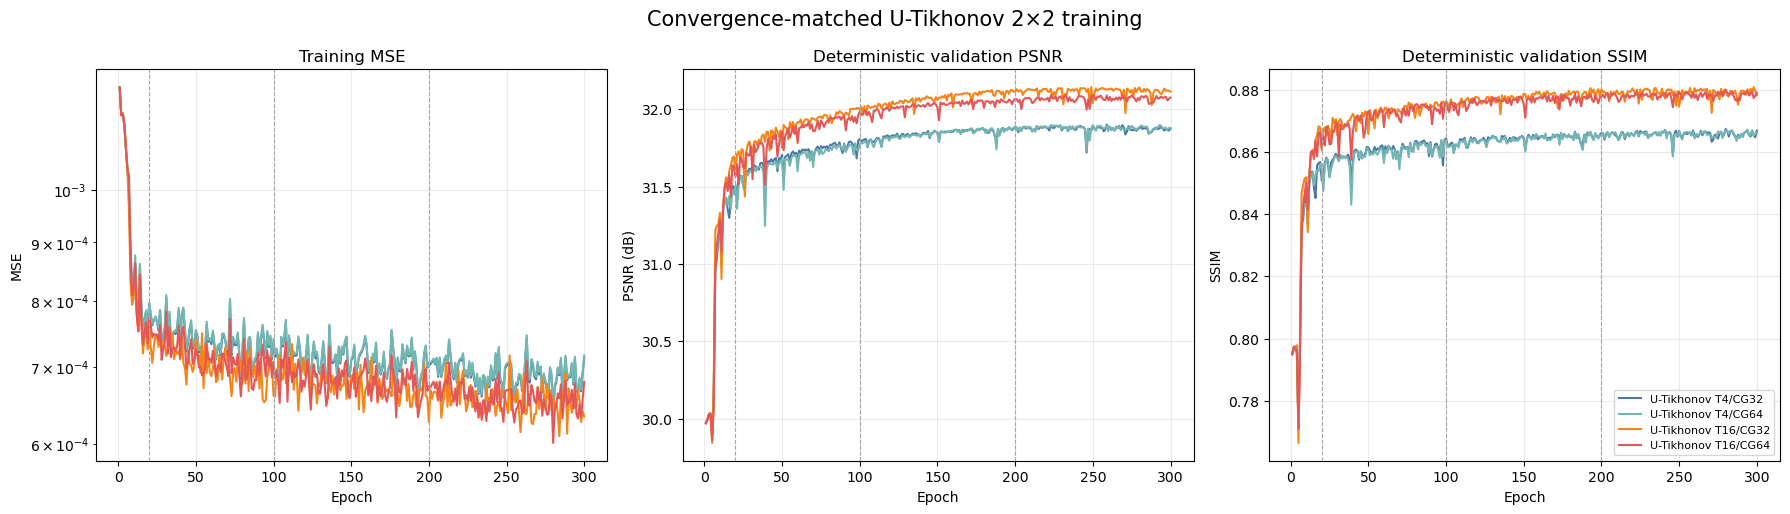

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tikhonov_convergence_matched_2x2_training_curves.png


In [11]:
colors = {
    "U-Tikhonov T4/CG32": "#4c78a8",
    "U-Tikhonov T4/CG64": "#72b7b2",
    "U-Tikhonov T16/CG32": "#f58518",
    "U-Tikhonov T16/CG64": "#e45756",
}
figure, axes = plt.subplots(1, 3, figsize=(18, 5.2))

for method, history in histories.items():
    color = colors[method]
    axes[0].plot(history["epoch"], history["train_mse"], color=color, label=method)
    axes[1].plot(history["epoch"], history["val_psnr"], color=color, label=method)
    axes[2].plot(history["epoch"], history["val_ssim"], color=color, label=method)

for axis in axes:
    for boundary in (20, 100, 200):
        axis.axvline(boundary, color="0.65", linestyle="--", linewidth=0.8)
    axis.grid(alpha=0.25)
    axis.set_xlabel("Epoch")

axes[0].set(title="Training MSE", ylabel="MSE")
axes[0].set_yscale("log")
axes[1].set(title="Deterministic validation PSNR", ylabel="PSNR (dB)")
axes[2].set(title="Deterministic validation SSIM", ylabel="SSIM")
axes[2].legend(fontsize=8, loc="lower right")

figure.suptitle("Convergence-matched U-Tikhonov 2×2 training", fontsize=15)
figure.tight_layout()
figure_path = output_dir / "u_tikhonov_convergence_matched_2x2_training_curves.png"
figure.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)
print("Saved:", figure_path)
